# Transfer: A Model-Building Checklist

This notebook turns the module into a checklist you can reuse on homework or a new small regression problem.

By the end of this notebook, you should be able to:

- start a regression analysis from a practical question rather than a software menu;
- combine model fitting, diagnostics, unusual-observation checks, and selection carefully;
- write a short regression report that separates evidence, assumptions, and decisions;
- know when a model is not ready to use.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

sales = pd.read_csv(Path('data/territory_sales.csv'))

## Checklist

Use this sequence when you face a new regression problem:

1. Define the response, predictors, units, and intended use.
2. Plot the response against key predictors and inspect predictor relationships.
3. Fit an initial model that is plausible, not just convenient.
4. Interpret coefficients conditionally and check whether signs make practical sense.
5. Check residual assumptions: form, variance, normality if needed, and independence if ordered.
6. Check multicollinearity with correlations and VIF.
7. Check unusual observations with studentized residuals, leverage, Cook's distance, and DFFITS.
8. If using variable selection, treat it as screening and then re-run diagnostics.
9. Check prediction settings for hidden extrapolation.
10. Report the final model with limitations.

In [3]:
formula = 'Sales ~ Time + MarketPotential + Advertising + Workload + Rating + CompetitorPressure'
model = smf.ols(formula, data=sales).fit()
print(model.summary().tables[1])
print('Adjusted R-squared:', round(model.rsquared_adj, 4))
print('Durbin-Watson:', round(durbin_watson(model.resid), 3))

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          -1.956e+04    1.4e+04     -1.392      0.174   -4.83e+04    9173.636
Time                -263.3041    105.103     -2.505      0.018    -478.264     -48.344
MarketPotential        0.5098      0.220      2.320      0.028       0.060       0.959
Advertising            4.8948      1.540      3.178      0.004       1.745       8.045
Workload             -35.7562    100.792     -0.355      0.725    -241.899     170.387
Rating               457.4668    868.821      0.527      0.603   -1319.472    2234.406
CompetitorPressure  -106.4399     85.618     -1.243      0.224    -281.549      68.669
Adjusted R-squared: 0.6926
Durbin-Watson: 2.028


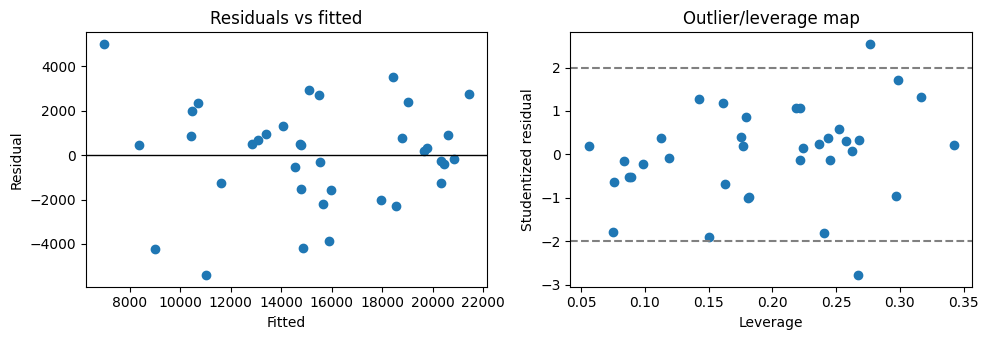

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(model.fittedvalues, model.resid)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Fitted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs fitted')
infl = model.get_influence().summary_frame()
axes[1].scatter(infl['hat_diag'], infl['student_resid'])
axes[1].axhline(2, color='gray', linestyle='--')
axes[1].axhline(-2, color='gray', linestyle='--')
axes[1].set_xlabel('Leverage')
axes[1].set_ylabel('Studentized residual')
axes[1].set_title('Outlier/leverage map')
plt.tight_layout()

In [5]:
X = model.model.exog
names = model.model.exog_names
vif = pd.DataFrame({'term': names, 'VIF': [variance_inflation_factor(X, i) for i in range(X.shape[1])]})
vif[vif['term'] != 'Intercept'].sort_values('VIF', ascending=False)

,term,VIF
1,Time,63.013559
2,MarketPotential,48.022769
3,Advertising,12.333011
5,Rating,2.670474
6,CompetitorPressure,1.991266
4,Workload,1.735970


## Categorical Predictors, Interactions, and Nested Tests

A categorical predictor enters a regression model through dummy variables. For a two-level factor, one level is the reference group and the dummy coefficient is the fitted difference from that reference group.

The small example below uses a teaching data set, not the homework data. `Stock = 1` marks a stock firm and `Stock = 0` marks a mutual firm. In the model

$$
Months=\beta_0+\beta_1 Size+\beta_2 Stock+\epsilon,
$$

$\beta_2$ is the fitted difference between stock and mutual firms **holding size fixed**. A separate unadjusted comparison, `Months ~ Stock`, answers a different question: the overall group difference without adjusting for size.

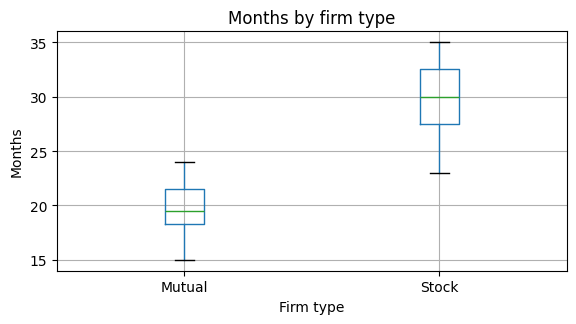

In [6]:
training_firms = pd.DataFrame({
    'Months': [15, 18, 20, 24, 23, 27, 31, 35, 19, 22, 29, 33],
    'Size':   [80, 110, 140, 180, 90, 130, 170, 210, 100, 150, 190, 230],
    'Stock':  [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1],
})
training_firms['Type'] = training_firms['Stock'].map({0: 'Mutual', 1: 'Stock'})

fig, ax = plt.subplots(figsize=(6, 3.5))
training_firms.boxplot(column='Months', by='Type', ax=ax)
ax.set_title('Months by firm type')
ax.figure.suptitle('')
ax.set_xlabel('Firm type')
ax.set_ylabel('Months')
plt.tight_layout()


In [7]:
size_only = smf.ols('Months ~ Size', data=training_firms).fit()
adjusted_type = smf.ols('Months ~ Size + Stock', data=training_firms).fit()
unadjusted_type = smf.ols('Months ~ Stock', data=training_firms).fit()

print('Adjusted size + type model')
print(adjusted_type.summary().tables[1])
print('\nUnadjusted type comparison')
print(unadjusted_type.summary().tables[1])
print('\n95% CI for unadjusted Stock - Mutual difference')
print(unadjusted_type.conf_int(alpha=0.05).loc['Stock'])


Adjusted size + type model
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.7410      1.375      7.083      0.000       6.630      12.852
Size           0.0784      0.010      7.943      0.000       0.056       0.101
Stock          6.6044      0.918      7.195      0.000       4.528       8.681

Unadjusted type comparison
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.6667      1.542     12.754      0.000      16.231      23.102
Stock         10.0000      2.181      4.586      0.001       5.141      14.859

95% CI for unadjusted Stock - Mutual difference
0     5.141045
1    14.858955
Name: Stock, dtype: float64


An interaction lets the slope of a quantitative predictor differ by group. In

$$
Months=\beta_0+\beta_1 Size+\beta_2 Stock+\beta_3(Size\times Stock)+\epsilon,
$$

mutual firms have fitted size slope $\beta_1$, while stock firms have fitted size slope $\beta_1+\beta_3$.

In [8]:
interaction_model = smf.ols('Months ~ Size * Stock', data=training_firms).fit()
print(interaction_model.summary().tables[1])

b = interaction_model.params
print(f"Mutual size slope: {b['Size']:.4f}")
print(f"Stock size slope: {b['Size'] + b['Size:Stock']:.4f}")


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.2574      2.373      3.902      0.005       3.786      14.729
Size           0.0822      0.018      4.538      0.002       0.040       0.124
Stock          7.4092      3.270      2.266      0.053      -0.130      14.949
Size:Stock    -0.0057      0.022     -0.258      0.803      -0.057       0.045
Mutual size slope: 0.0822
Stock size slope: 0.0765


For nested models, a partial F test compares a reduced model with a complete model. The null hypothesis says that the predictors added in the complete model have zero coefficients after the reduced model is already included.

In Python, `complete_model.compare_f_test(reduced_model)` returns the F statistic, p-value, and numerator degrees of freedom.

In [9]:
f_stat, p_value, df_diff = adjusted_type.compare_f_test(size_only)
print(f"Partial F statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4g}")
print(f"added degrees of freedom: {df_diff:.0f}")


Partial F statistic: 51.7733
p-value: 5.109e-05
added degrees of freedom: 1


## Report Template

A concise regression report should include:

- the question and data context;
- the fitted model and units;
- coefficient interpretation for the key predictors;
- inference or prediction results that answer the question;
- diagnostics and any unusual observations;
- a clear limitation statement, especially for observational data, extrapolation, and model selection.

Transfer exercise: choose one model from this module and write a five-sentence report using the template above.